In [1]:
# Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import kagglehub
import kaggle 
from googleapiclient.discovery import build
from dotenv import load_dotenv
import os

# Youtube API 
load_dotenv()
api_key = os.getenv("YOUTUBE_API_KEY")
youtube = build("youtube", "v3", developerKey=api_key)

# Kaggle Dataset
os.environ["KAGGLE_USERNAME"] = os.getenv("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = os.getenv("KAGGLE_KEY")
kaggle.api.authenticate()
kaggle.api.dataset_download_files("datasnaek/youtube-new", path="./data", unzip=True)
df_kaggle = pd.read_csv("./data/USvideos.csv")

print(df_kaggle.shape)
print(df_kaggle.head())


Dataset URL: https://www.kaggle.com/datasets/datasnaek/youtube-new
(40949, 16)
      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   
3  puqaWrEC7tY      17.14.11   
4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE           CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...        LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...           Rudy Mancuso   
3                   Nickelback Lyrics: Real or Fake?  Good Mythical Morning   
4                           I Dare You: GOING BALD!?               nigahiga   

   category_id              publish_time  \
0           22  2017-11-13T17:13:01.000Z   
1           24  2017-11-13T07:30:00.000Z   
2           23  2017-11-12T19:05:24.000Z   
3           24  2017-11-13T11:00:04.000Z   
4           24  2017-11-12T18:01:

In [2]:
# Merge the YAPI and the KAPI 

print(df_kaggle["video_id"].head(10))
print(df_kaggle["video_id"].nunique())

print(df_kaggle["video_id"].nunique())


0    2kyS6SvSYSE
1    1ZAPwfrtAFY
2    5qpjK5DgCt4
3    puqaWrEC7tY
4    d380meD0W0M
5    gHZ1Qz0KiKM
6    39idVpFF7NQ
7    nc99ccSXST0
8    jr9QtXwC9vc
9    TUmyygCMMGA
Name: video_id, dtype: object
6351
6351


In [3]:
# Get unique video IDs
video_ids = df_kaggle["video_id"].dropna().unique().tolist()

# Fetch in batches of 50
rows = []
for i in range(0, len(video_ids), 50):
    batch = video_ids[i:i+50]
    request = youtube.videos().list(
        part="snippet,statistics",
        id=",".join(batch)
    )
    response = request.execute()
    
    for item in response["items"]:
        rows.append({
            "video_id":  item["id"],
            "title":     item["snippet"]["title"],
            "channel":   item["snippet"]["channelTitle"],
            "published": item["snippet"]["publishedAt"],
            "views":     int(item["statistics"].get("viewCount", 0)),
            "likes":     int(item["statistics"].get("likeCount", 0)),
            "comments":  int(item["statistics"].get("commentCount", 0)),
        })

df_api = pd.DataFrame(rows)
print(df_api.shape)
print(df_api.head())

(5688, 7)
      video_id                                              title  \
0  2kyS6SvSYSE                 WE WANT TO TALK ABOUT OUR MARRIAGE   
1  1ZAPwfrtAFY  The Trump Presidency: Last Week Tonight with J...   
2  puqaWrEC7tY                   Nickelback Lyrics: Real or Fake?   
3  d380meD0W0M                           I Dare You: GOING BALD!?   
4  gHZ1Qz0KiKM                              2 Weeks with iPhone X   

                 channel             published     views   likes  comments  
0           CaseyNeistat  2017-11-13T17:13:01Z   2983324  102173     20018  
1        LastWeekTonight  2017-11-13T07:30:00Z  23211539  262948     22449  
2  Good Mythical Morning  2017-11-13T11:00:04Z   1451231   21714      3199  
3               nigahiga  2017-11-12T18:01:41Z   5056099  190747     22322  
4               iJustine  2017-11-13T19:07:23Z   2190573   37697      3271  


In [ ]:
df = pd.merge(df_kaggle, df_api, on="video_id", how="inner")
print(df.shape)
print(df.columns.tolist())

# Little note: This is actually really interesting — 
# you can compare 2017 view/like counts (kaggle) vs current counts (API) to see how
# much videos have grown.

In [ ]:
# Little cleaning

df = df.drop(columns=["title_y", "channel"])
df = df.rename(columns={
    "title_x":        "title",
    "views_x":        "views_2017",
    "likes_x":        "likes_2017",
    "views_y":        "views_current",
    "likes_y":        "likes_current",
    "comment_count":  "comments_2017",
    "comments":       "comments_current"
})

print(df.columns.tolist())

In [ ]:
# Null and type check
print(df.dtypes)
print(df.isnull().sum())

In [ ]:
# Cleaning: Convert formats of dates to datetime objects
df["trending_date"] = pd.to_datetime(df["trending_date"], format="%y.%d.%m")
df["publish_time"] = pd.to_datetime(df["publish_time"])
df["published"] = pd.to_datetime(df["published"])

print(df[["trending_date", "publish_time", "published"]].dtypes)
print(df[["trending_date", "publish_time", "published"]].head())

In [ ]:
# EDA on growth: how much have views/likes grown from 2017 to now?

# Growth Analysis
df["view_growth"] = df["views_current"] - df["views_2017"]
df["like_growth"] = df["likes_current"] - df["likes_2017"]
df["comment_growth"] = df["comments_current"] - df["comments_2017"]

print(df[["title", "view_growth", "like_growth", "comment_growth"]].describe())

# Top 10 most grown videos
print(df[["title", "view_growth"]].sort_values("view_growth", ascending=False).head(10))

# Visualize view growth distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["view_growth"], log_scale=True, bins=50)
plt.title("Distribution of View Growth (2017 to Current)")
plt.xlabel("View Growth")
plt.show()


# What we see: 
The average video gained about 22.7 million views since 2017
The median (50%) is 1.6 million — meaning most videos grew modestly, but a few viral videos are pulling the mean way up
Some videos have negative growth (min is -12 million) — this happens when the Kaggle data captured a video at its peak viral moment and views were later removed or the count was corrected by YouTube
Ed Sheeran's "Perfect" and Maroon 5's "Girls Like You" dominate — both gained 4 billion+ views since 2017
You're seeing the same video multiple times because the Kaggle dataset has duplicate rows for videos that trended on multiple days (deduplicating below)

In [ ]:
# Deduplicating the videos 
df_unique = df.drop_duplicates(subset="video_id")

print(df_unique[["title", "view_growth"]].sort_values("view_growth", ascending=False).head(10))
plt.figure(figsize=(10, 5))
sns.histplot(df_unique["view_growth"], log_scale=True, bins=50)
plt.title("Distribution of View Growth (2017 to Current)")
plt.xlabel("View Growth")
plt.show()

In [ ]:
# EDA on trending patterns: what days/months had the most trending videos?

# Trending Patterns
df["day_of_week"] = df["trending_date"].dt.day_name()
df["month"] = df["trending_date"].dt.month_name()

# Videos trending by day of week
plt.figure(figsize=(10, 5))
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.countplot(data=df, x="day_of_week", order=day_order)
plt.title("Number of Trending Videos by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.show()

# Videos trending by month
plt.figure(figsize=(10, 5))
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
sns.countplot(data=df, x="month", order=month_order)
plt.title("Number of Trending Videos by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# What we see:
Day of Week:
Trending videos are almost perfectly evenly distributed across all 7 days — about 5,200-5,400 per day. This means YouTube's trending algorithm doesn't really favor any particular day of the week. Not super interesting but good to know
Month:
This one is more telling. The dataset only covers November 2017 through June 2018 — that's why July through October are completely empty. Within the data you have:

March and May are the peak months (~5,600 trending videos each)
June drops off sharply (~2,500) because the dataset ends partway through June
November is lower (~3,000) because the dataset starts partway through November

So the monthly pattern is mostly reflecting the coverage of the dataset rather than a true seasonal trend. Worth noting that caveat in your project writeup!

In [ ]:
# EDA on Category: which categories get the most views/engagement?

category_map = {
    1: "Film & Animation", 2: "Autos & Vehicles", 10: "Music",
    15: "Pets & Animals", 17: "Sports", 19: "Travel & Events",
    20: "Gaming", 22: "People & Blogs", 23: "Comedy",
    24: "Entertainment", 25: "News & Politics", 26: "Howto & Style",
    27: "Education", 28: "Science & Technology", 29: "Nonprofits & Activism"
}
df["category"] = df["category_id"].map(category_map)

# Views by category
plt.figure(figsize=(12, 6))
cat_views = df.groupby("category")["views_current"].mean().sort_values(ascending=False)
sns.barplot(x=cat_views.values, y=cat_views.index)
plt.title("Average Current Views by Category")
plt.xlabel("Average Views")
plt.show()

# What we see:
Music dominates by a massive margin averaging over 1.1 billion views per video, which is roughly 10x more than the next category (Film & Animation at ~130 million). This makes total sense given what we saw in the growth analysis — the top growers were all music videos like Ed Sheeran and Maroon 5.
The rest of the categories are fairly close to each other, all under 200 million average views. A few interesting notes:

News & Politics is dead last — news videos get views quickly but don't have long term staying power like music does
Sports comes in 3rd which is surprising given it's often considered time-sensitive content
Gaming is lower than you might expect given how big YouTube gaming is

In [ ]:
# EDA on engagement: ratio, comment ratio by channel or category?

df_unique["category"] = df_unique["category_id"].map(category_map)
df_unique["like_rate"] = df_unique["likes_current"] / df_unique["views_current"]
df_unique["comment_rate"] = df_unique["comments_current"] / df_unique["views_current"]

# Like rate by category
plt.figure(figsize=(12, 6))
cat_likes = df_unique.groupby("category")["like_rate"].mean().sort_values(ascending=False)
sns.barplot(x=cat_likes.values, y=cat_likes.index)
plt.title("Average Like Rate by Category")
plt.xlabel("Likes / Views")
plt.show()

#What we see: 
Music gets the most views but not the most engagement it sits in the middle for like rate at about 1.8%.
The standouts:
People & Blogs has the highest like rate (~2.8%) — these are personal/creator channels where audiences are highly loyal and engaged
Nonprofits & Activism and Comedy are close behind — content that resonates emotionally drives more active engagement
Education, Howto & Style, and Film & Animation are near zero which looks suspicious — likely a data issue with very few videos in those categories skewing the result
News & Politics and Sports are lowest which makes sense — people watch but don't necessarily like

The key takeaway for your project: views and engagement are different things. Music wins on scale, but smaller creator-driven categories win on audience loyalty.

In [ ]:
# Time, Trend: how long after publishing does a video start trending

# Time to Trend
df_unique["time_to_trend"] = (df_unique["trending_date"] - df_unique["publish_time"].dt.tz_localize(None)).dt.days

print(df_unique["time_to_trend"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df_unique["time_to_trend"].clip(0, 30), bins=30)
plt.title("Days from Publishing to Trending")
plt.xlabel("Days")
plt.show()

#What we see: 
Most videos trend within the first 2-3 days of being published, the spike at day 0-1 is huge, meaning YouTube's algorithm picks up viral content almost immediately after upload.
After day 5 it drops off dramatically, and by day 10 almost nothing is trending for the first time.
The small bump at day 30 on the right is an artifact of the .clip(0, 30) — that bar represents all videos that took longer than 30 days to trend, lumped together at the 30 mark. There are a handful of those, likely older videos that got a second life from being referenced or shared.
What did the describe() print? That'll tell us the exact median and mean. But overall the takeaway for your project is: if a video doesn't trend within a week of publishing, it almost certainly won't trend at all.

In [1]:
from cleaning import run_cleaning_pipeline
df = run_cleaning_pipeline()

Running cleaning pipeline...
Done! Shape: (37095, 20)


Running cleaning pipeline...
Done! Shape: (37095, 20)
Running analysis pipeline...
        view_growth   like_growth  comment_growth
count  5.687000e+03  5.687000e+03    5.687000e+03
mean   1.542200e+07  1.465200e+05    6.166925e+03
std    1.177719e+08  8.550703e+05    6.674916e+04
min   -3.979200e+05 -1.193200e+04   -1.205350e+05
25%    2.437575e+05  2.801500e+03    3.100000e+01
50%    1.200046e+06  1.628800e+04    5.110000e+02
75%    4.824178e+06  7.050250e+04    2.524500e+03
max    4.107027e+09  2.887934e+07    3.754179e+06
                                                   title  view_growth
58           Ed Sheeran - Perfect (Official Music Video)   4107026898
34360              Maroon 5 - Girls Like You ft. Cardi B   3996201082
534            Luis Fonsi, Demi Lovato - Échame La Culpa   2499360779
28348               Billie Eilish - lovely (with Khalid)   2404734021
27051  Becky G, Natti Natasha - Sin Pijama (Official ...   2312566329
34181  Cardi B, Bad Bunny & J Balvin - I Like I

/Users/summerprice/Desktop/WINTER_26/STAT_386/final_project386/src/final_project_demo/analysis.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique["view_growth"] = df_unique["views_current"] - df_unique["views_2017"]
/Users/summerprice/Desktop/WINTER_26/STAT_386/final_project386/src/final_project_demo/analysis.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique["like_growth"] = df_unique["likes_current"] - df_unique["likes_2017"]
/Users/summerprice/Desktop/WINTER_26/STAT_386/final_proj

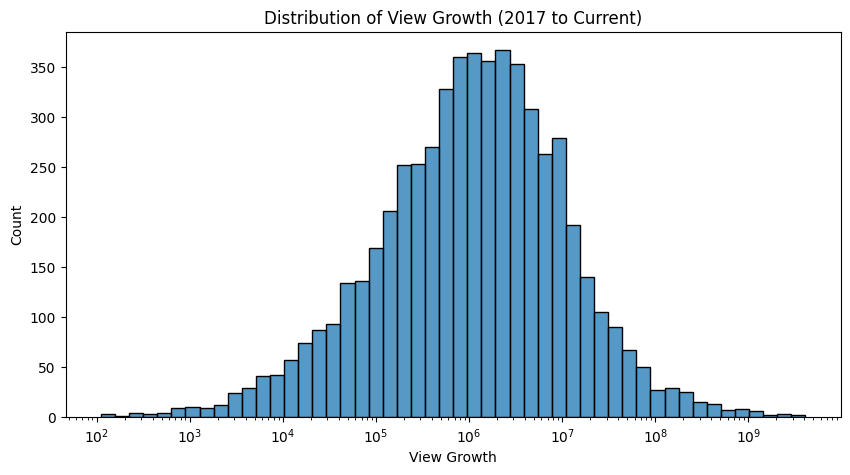

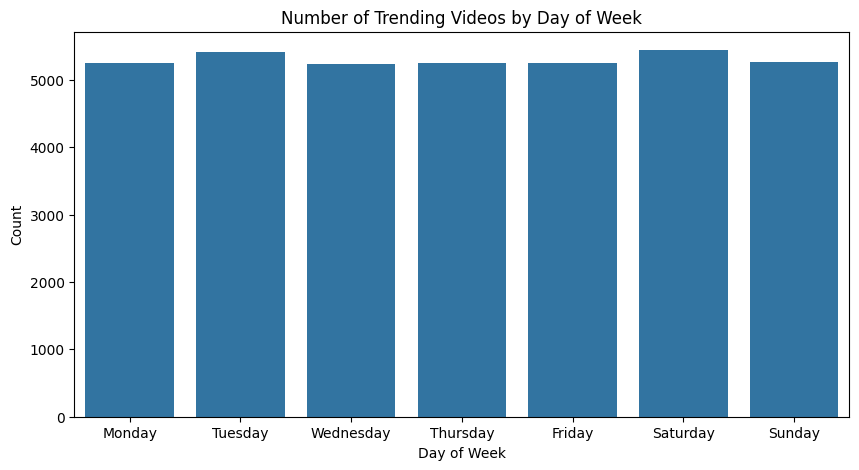

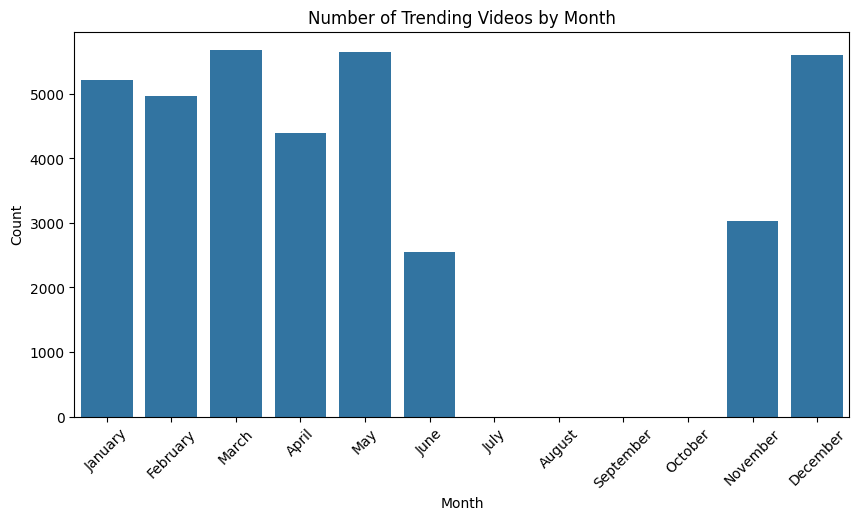

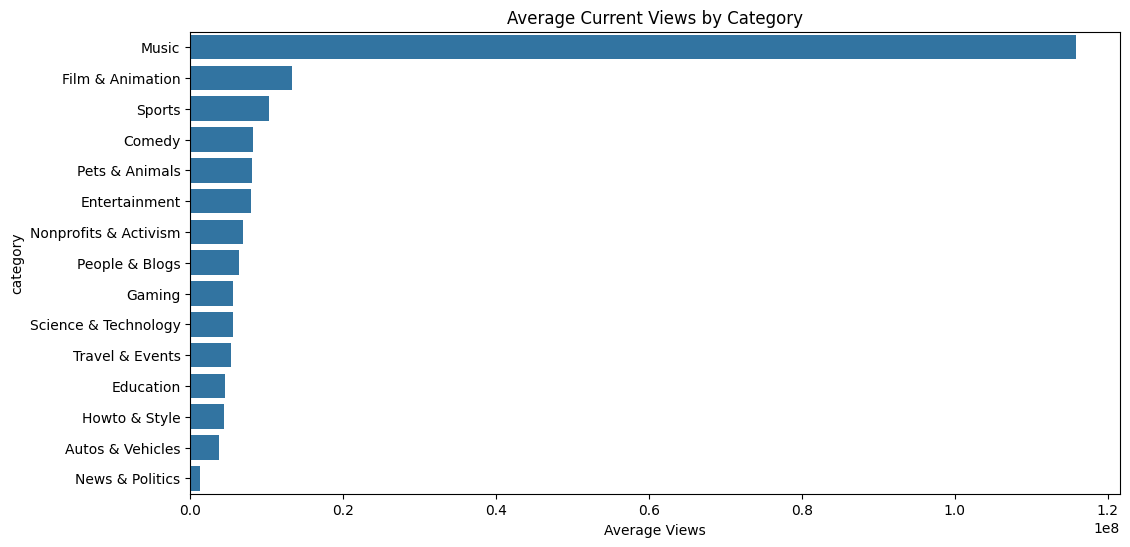

/Users/summerprice/Desktop/WINTER_26/STAT_386/final_project386/src/final_project_demo/analysis.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique["category"] = df_unique["category_id"].map(category_map)
/Users/summerprice/Desktop/WINTER_26/STAT_386/final_project386/src/final_project_demo/analysis.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique["like_rate"] = df_unique["likes_current"] / df_unique["views_current"]
/Users/summerprice/Desktop/WINTER_26/STAT_386/final_project386/src/f

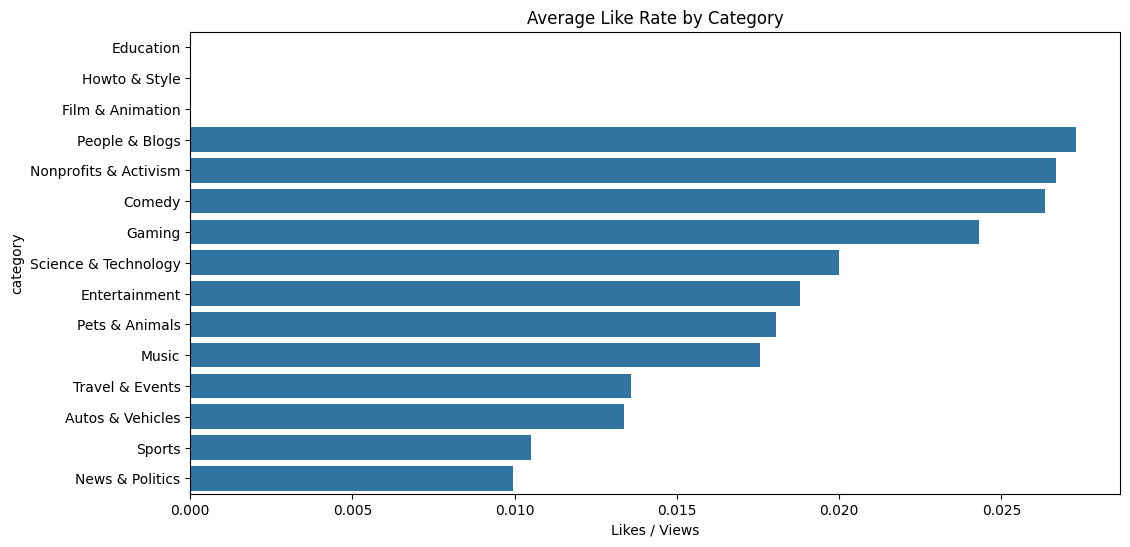

/Users/summerprice/Desktop/WINTER_26/STAT_386/final_project386/src/final_project_demo/analysis.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique["time_to_trend"] = (df_unique["trending_date"] - df_unique["publish_time"].dt.tz_localize(None)).dt.days


count    5687.000000
mean       19.877616
std       200.107527
min        -1.000000
25%         0.000000
50%         1.000000
75%         2.000000
max      3562.000000
Name: time_to_trend, dtype: float64


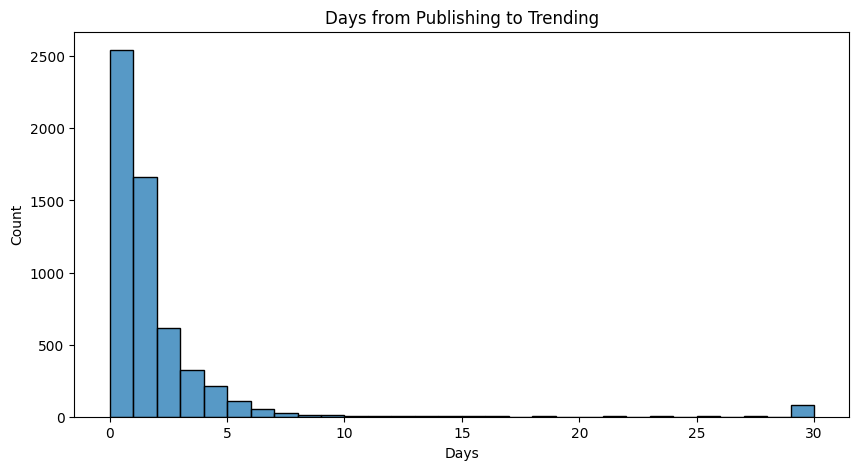

Analysis complete!


In [2]:
from final_project_demo import run_cleaning_pipeline, run_analysis_pipeline
df = run_cleaning_pipeline()
run_analysis_pipeline(df)

In [ ]:
# Actual Analysis
# 1 — Predicting view count
# Can you predict how many views a video will get based on likes, comments, category, and time to trend? 

# 2 — What features predict a video trending quickly?
# Use regression to predict time_to_trend based on category, publish time, likes, etc.
# "what makes a video trend fast?"

# 3 — View growth over time
# Model how much a video grows from 2017 to now based on its category and initial engagement.

In [3]:
print(df.columns.tolist())
print(df.dtypes)

['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views_2017', 'likes_2017', 'dislikes', 'comments_2017', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description', 'published', 'views_current', 'likes_current', 'comments_current']
video_id                               object
trending_date                  datetime64[ns]
title                                  object
channel_title                          object
category_id                             int64
publish_time              datetime64[ns, UTC]
tags                                   object
views_2017                              int64
likes_2017                              int64
dislikes                                int64
comments_2017                           int64
thumbnail_link                         object
comments_disabled                        bool
ratings_disabled                         bool
video_error_or_removed               

In [7]:
# Option 1: Predicting current views based on 2017 engagement and category
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pandas as pd

df_model = df.drop_duplicates(subset="video_id").copy()

features = ["likes_2017", "dislikes", "comments_2017", "category_id", 
            "comments_disabled", "ratings_disabled"]

X = df_model[features].copy()
X["comments_disabled"] = X["comments_disabled"].astype(int)
X["ratings_disabled"] = X["ratings_disabled"].astype(int)

# Log transform target to handle skew
y = np.log1p(df_model["views_current"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model1 = RandomForestRegressor(n_estimators=100, random_state=42)
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"MAE (log scale): {mean_absolute_error(y_test, y_pred):.3f}")

importances = pd.Series(model1.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

R² Score: 0.679
MAE (log scale): 0.962
likes_2017           0.714358
dislikes             0.102766
comments_2017        0.100991
category_id          0.077870
ratings_disabled     0.002861
comments_disabled    0.001154
dtype: float64


Key Insights: 
R² of 0.679 — the model explains about 68% of the variance in current views. That's pretty decent for social media data which is inherently noisy
MAE of 0.962 (log scale) — on average the model's predictions are off by about 0.96 in log scale, which translates to roughly being off by a factor of 2.6x in actual views. Not bad given how unpredictable virality is.
Feature importances:

likes_2017 is by far the most important feature at 71% — early likes are the strongest signal of long term success
dislikes and comments_2017 are roughly equal at ~10% each — engagement in general matters, even negative engagement
category_id contributes about 8% — the type of content matters but less than engagement
comments_disabled and ratings_disabled are nearly irrelevant

Key insight: early engagement (especially likes) is the strongest predictor of a video's long term view count. videos that people engage with early get boosted by YouTube's algorithm. Pretty intuitive. 

In [8]:
# Option 2: Predicting time to trend
df_model["time_to_trend"] = (df_model["trending_date"] - df_model["publish_time"].dt.tz_localize(None)).dt.days
df_model = df_model[df_model["time_to_trend"] >= 0]  # remove negative values

# Extract time features from publish_time
df_model["publish_hour"] = df_model["publish_time"].dt.hour
df_model["publish_day"] = df_model["publish_time"].dt.dayofweek

features3 = ["likes_2017", "views_2017", "comments_2017", "category_id", 
             "publish_hour", "publish_day", "comments_disabled", "ratings_disabled"]

X3 = df_model[features3].copy()
X3["comments_disabled"] = X3["comments_disabled"].astype(int)
X3["ratings_disabled"] = X3["ratings_disabled"].astype(int)

y3 = np.log1p(df_model["time_to_trend"])

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

model3 = RandomForestRegressor(n_estimators=100, random_state=42)
model3.fit(X3_train, y3_train)
y3_pred = model3.predict(X3_test)

print(f"R² Score: {r2_score(y3_test, y3_pred):.3f}")
print(f"MAE (log scale): {mean_absolute_error(y3_test, y3_pred):.3f}")

importances3 = pd.Series(model3.feature_importances_, index=features3).sort_values(ascending=False)
print(importances3)

R² Score: 0.274
MAE (log scale): 0.539
comments_2017        0.285657
likes_2017           0.199109
views_2017           0.191379
publish_hour         0.125758
category_id          0.106989
publish_day          0.073656
comments_disabled    0.016361
ratings_disabled     0.001091
dtype: float64


R² of 0.274 — the model explains about 27% of the variance in time to trend. This is lower than Option 1, which actually makes sense — how quickly a video trends is harder to predict than its long term views. There's a lot of randomness in what YouTube's algorithm picks up quickly.
MAE of 0.539 (log scale) — predictions are off by about half a log unit, meaning roughly 1-2 days in actual time.
Feature importances:

comments_2017 is the top predictor at 29% — videos that generate a lot of discussion trend faster
likes_2017 and views_2017 are close behind at 20% and 19% — overall early engagement matters
publish_hour at 13% — the time of day you post actually matters for trending speed!
category_id at 11% — some categories trend faster than others
publish_day at 7% — day of week has some influence but less than hour
comments_disabled at 1.6% — slightly interesting, videos with comments enabled trend faster

Key insight: comments are the strongest signal for trending speed, videos that spark conversation get picked up by the algorithm faster than videos that just get passively watched.

In [9]:
# Option 3: Predicting view growth
df_model["view_growth"] = df_model["views_current"] - df_model["views_2017"]

features5 = ["views_2017", "likes_2017", "comments_2017", "category_id", "time_to_trend"]

X5 = df_model[features5].copy()
y5 = np.log1p(df_model["view_growth"].clip(lower=0))  # clip negatives to 0

X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y5, test_size=0.2, random_state=42)

model5 = RandomForestRegressor(n_estimators=100, random_state=42)
model5.fit(X5_train, y5_train)
y5_pred = model5.predict(X5_test)

print(f"R² Score: {r2_score(y5_test, y5_pred):.3f}")
print(f"MAE (log scale): {mean_absolute_error(y5_test, y5_pred):.3f}")

importances5 = pd.Series(model5.feature_importances_, index=features5).sort_values(ascending=False)
print(importances5)

R² Score: 0.669
MAE (log scale): 1.049
likes_2017       0.623573
views_2017       0.163009
comments_2017    0.094775
category_id      0.084763
time_to_trend    0.033880
dtype: float64


R² of 0.669 — the model explains about 67% of the variance in view growth, very similar to Option 1. That's a strong result!
MAE of 1.049 (log scale) — predictions are off by about 1 log unit, roughly a factor of 3x in actual views.
Feature importances:
likes_2017 dominates at 62% — early likes are the strongest predictor of long term growth, consistent with what we saw in Option 1
views_2017 at 16% — videos that already had more views in 2017 tend to grow more
comments_2017 at 9% and category_id at 8% — both contribute meaningfully
time_to_trend at only 3% — surprisingly, how fast a video trended doesn't predict how much it grows long term

Key insight: early likes are the single strongest predictor of view growth over time. This is consistent across all three models — likes are the most important signal YouTube's algorithm uses to decide which videos to keep promoting.